In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from MoG import MoG

In [3]:
def create_data(n_samples_per_class=500, device="cpu"):
    # 2 gaussians
    dist1 = torch.distributions.MultivariateNormal(
        loc=torch.tensor([4.0, 0.0], device=device),
        covariance_matrix=torch.tensor([[2.0, 0.0], [0.0, 2.0]], device=device)
    )
    
    dist2 = torch.distributions.MultivariateNormal(
        loc=torch.tensor([0.0, 4.0], device=device),
        covariance_matrix=torch.tensor([[2.0, 0.0], [0.0, 2.0]], device=device)
    )
    
    # sample
    X1 = dist1.sample((n_samples_per_class,))
    X2 = dist2.sample((n_samples_per_class,))
    
    # cat
    X = torch.cat([X1, X2], dim=0)
    
    # labels
    y = torch.cat([
        torch.zeros(n_samples_per_class, dtype=torch.long, device=device),
        torch.ones(n_samples_per_class, dtype=torch.long, device=device)
    ])
    
    return X, y

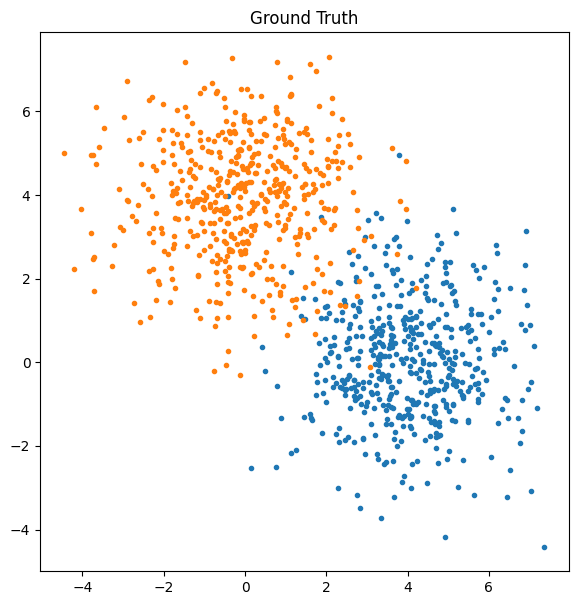

In [4]:
X, y = create_data()

X = X.detach().cpu()
y = y.detach().cpu()

X_np = X.numpy()
y_np = y.numpy()

plt.figure(figsize=(15, 7))

#  Ground Truth
plt.subplot(1, 2, 1)
plt.title("Ground Truth")
plt.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], marker=".")
plt.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], marker=".")

# MoG

In [5]:
mog = MoG(K=2)
mog.fit(X)
y_pred = mog.predict(X)

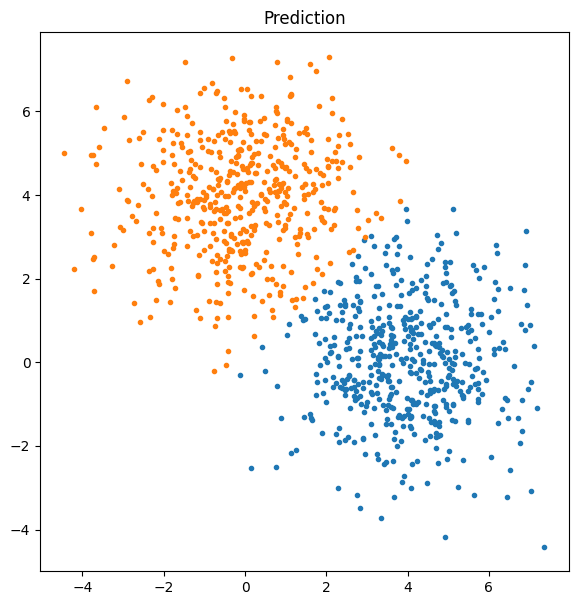

In [9]:
y_pred_np = y_pred.detach().cpu().numpy()
# --- Prediction ---
plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.title("Prediction")
plt.scatter(X_np[y_pred_np == 0, 0], X_np[y_pred_np == 0, 1], marker=".")
plt.scatter(X_np[y_pred_np == 1, 0], X_np[y_pred_np == 1, 1], marker=".")

plt.show()